C:\Users\dongs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2QS-DEC will be used.
  self._init_dates(dates, freq)
C:\Users\dongs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2QS-DEC will be used.
  self._init_dates(dates, freq)
C:\Users\dongs\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\dongs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 2QS-DEC will be used.
  self._init_dates(dates, freq)
C:\Users\dongs\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

Business School UG Students ARIMAX Summary:
                                        SARIMAX Results                                        
Dep. Variable:     #Students Business School Major(UG)   No. Observations:                   35
Model:                                SARIMAX(1, 1, 1)   Log Likelihood                -185.111
Date:                                 Wed, 12 Mar 2025   AIC                            380.222
Time:                                         14:09:43   BIC                            387.854
Sample:                                     09-01-2007   HQIC                           382.825
                                          - 09-01-2024                                         
Covariance Type:                                   opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Covid (1/0)   -26.7097   3.0

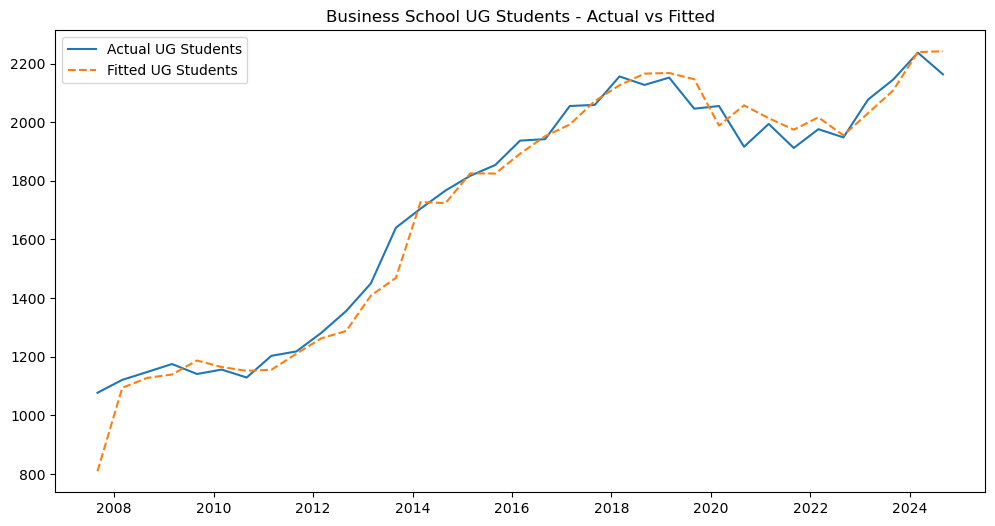

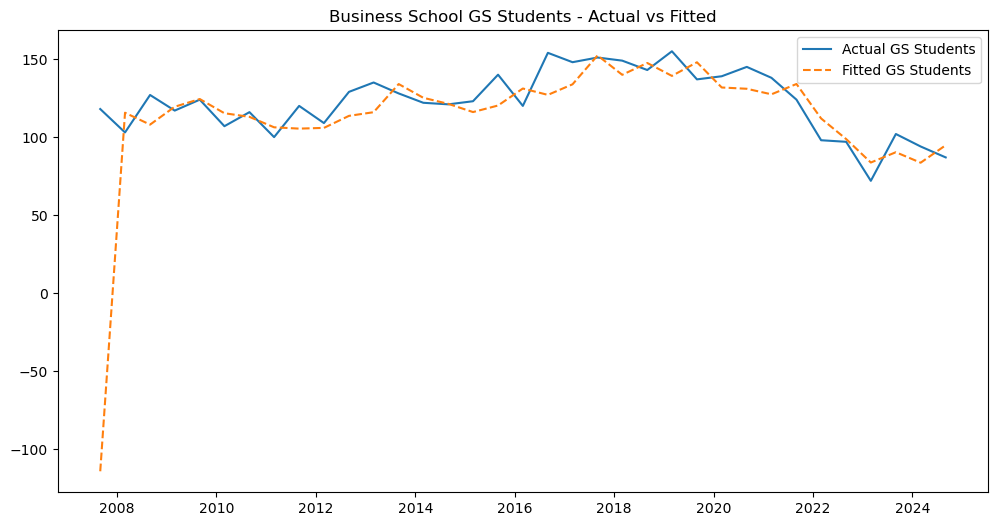

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Dataset.csv'  # Adjust if needed
df = pd.read_csv(file_path)

# --- Preprocessing ---

# Convert 'Year' to datetime format (Fall = Sept 1, Spring = March 1)
def parse_year(term):
    season, year = term.split()
    if season == 'Fall':
        return pd.to_datetime(f'{year}-09-01')
    elif season == 'Spring':
        return pd.to_datetime(f'{year}-03-01')
    else:
        raise ValueError(f"Unexpected term: {term}")

df['Date'] = df['Year '].apply(parse_year)
df = df.set_index('Date')

# Clean and convert Tuition Fees (optional - not used in this ARIMAX)
df['Tuition Fees (year) $ '] = (
    df[' Tuition Fees (year) $ ']
    .str.replace('[$,]', '', regex=True)
    .astype(float)
)

# --- Define Variables ---
# Target Variables
y_ug = df['#Students Business School Major(UG)']
y_gs = df['#Students Business School Major (GS)']

# Exogenous Variables
X = df[['Covid (1/0)', 'GDP (US)']]

# --- Fit ARIMAX Models ---
# UG Students Model
model_ug = SARIMAX(y_ug, exog=X, order=(1,1,1), seasonal_order=(0,0,0,0))
result_ug = model_ug.fit()
print("Business School UG Students ARIMAX Summary:")
print(result_ug.summary())

# GS Students Model
model_gs = SARIMAX(y_gs, exog=X, order=(1,1,1), seasonal_order=(0,0,0,0))
result_gs = model_gs.fit()
print("\nBusiness School GS Students ARIMAX Summary:")
print(result_gs.summary())

# --- Plot Actual vs Fitted ---
df['Fitted_UG'] = result_ug.fittedvalues
df['Fitted_GS'] = result_gs.fittedvalues

plt.figure(figsize=(12, 6))
plt.plot(df.index, y_ug, label="Actual UG Students")
plt.plot(df.index, df['Fitted_UG'], label="Fitted UG Students", linestyle='--')
plt.legend()
plt.title('Business School UG Students - Actual vs Fitted')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df.index, y_gs, label="Actual GS Students")
plt.plot(df.index, df['Fitted_GS'], label="Fitted GS Students", linestyle='--')
plt.legend()
plt.title('Business School GS Students - Actual vs Fitted')
plt.show()

In [11]:
print(df.columns)

Index(['Year ', 'NC Students', 'International Students', '#StudentsMajor(UG)',
       '#StudentsMajor (GS)', '#Students Business School Major(UG)',
       '#Students Business School Major (GS)',
       '#Business School Major/Program(UG)',
       '#Business School Major/Program (GS)', ' Tuition Fees (year) $ ',
       'Covid (1/0)', ' # of Covid Cases ', 'GDP (US)', 'GDP(NC)',
       'Elon Ranking (USA)', '# Total Majors (UG)', '#Total Major (GS)',
       'Tuition Fees (year) $ '],
      dtype='object')


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.74261D+00    |proj g|=  1.99452D-02

At iterate    5    f=  4.74125D+00    |proj g|=  1.59196D-03

At iterate   10    f=  4.73924D+00    |proj g|=  4.23312D-02

At iterate   15    f=  4.73523D+00    |proj g|=  1.88312D-03

At iterate   20    f=  4.73498D+00    |proj g|=  5.46953D-03

At iterate   25    f=  4.72559D+00    |proj g|=  2.12439D-02

At iterate   30    f=  4.71512D+00    |proj g|=  4.81345D-02

At iterate   35    f=  4.70903D+00    |proj g|=  1.53435D-02

At iterate   40    f=  4.70818D+00    |proj g|=  2.20622D-02

At iterate   45    f=  4.70677D+00    |proj g|=  9.15146D-04

At iterate   50    f=  4.70677D+00    |proj g|=  3.06443D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

 This problem is unconstrained.
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 This problem is unconstrained.


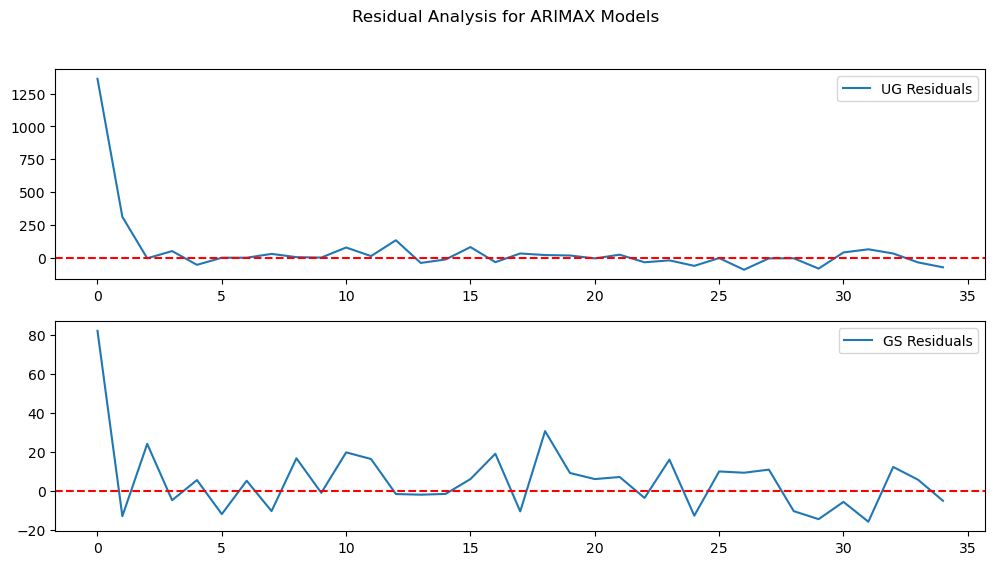

In [21]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler

# Load Data
df = pd.read_csv('Capstone DataSET(Sheet1).csv')
df.columns = df.columns.str.strip()  # Clean column names

# Standardize Exogenous Variables
scaler = StandardScaler()
df[['Covid (1/0)', 'GDP (US)']] = scaler.fit_transform(df[['Covid (1/0)', 'GDP (US)']])

# Define Exogenous Variables
exog_vars = df[['Covid (1/0)', 'GDP (US)']]

# Improved ARIMAX Model for UG Students
model_ug = SARIMAX(df['#Students Business School Major(UG)'], 
                    order=(2, 1, 2), 
                    exog=exog_vars,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
results_ug = model_ug.fit()
print("\nBusiness School UG Students ARIMAX Summary:")
print(results_ug.summary())

# Improved ARIMAX Model for GS Students
model_gs = SARIMAX(df['#Students Business School Major (GS)'], 
                    order=(0, 1, 1), 
                    exog=exog_vars,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
results_gs = model_gs.fit()
print("\nBusiness School GS Students ARIMAX Summary:")
print(results_gs.summary())

# Plotting residuals for improved diagnostics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(results_ug.resid, label='UG Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(results_gs.resid, label='GS Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.legend()

plt.suptitle('Residual Analysis for ARIMAX Models')
plt.show()
